# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Напишите заголовок первой части проекта здесь

- Автор: **Лавров Илья**
- Дата: **11.03.2026**

## Цели и задачи проекта

**Цель проекта:** проверка гипотезы, которая звучит следующим образом: "Пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы."

Задачи проекта:
- **подготовка данных перед проведением А/Б-тестирования**
- **проведение А/Б теста**
- **формулирование выводов и составление аналитической записки**

## Описание данных

На данном этапе мы работаем с таблицей `yandex_knigi_data`, где хранятся данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности.

В таблице есть следующие поля:
- `city` — город пользователя;
- `puid` — идентификатор пользователя;
- `hours` — общее количество часов активности.

## Содержимое проекта


### Часть 1. Проверка гипотезы в Python и составление аналитической записки
* [1. Загрузка данных таблицы `yandex_knigi_data` и знакомство с ними](#1-загрузка-данных-и-знакомство-с-ними)
* [2. Проверка гипотезы в Python](#2-проверка-гипотезы-в-python)
* [3. Составление аналитической записки](#3-аналитическая-записка)

### Часть 2. Анализ результатов A/B-тестирования
* [1. Описание цели исследования](#1-опишите-цели-исследования)
* [2. Загрузка данных и их предобработка](#2-загрузите-данные-оцените-их-целостность)
* [3. Оценка корректности проведения теста по таблице `ab_test_participants`](#3-по-таблице-ab_test_participants-оцените-корректность-проведения-теста)
* [4. Оценка результатов A/B-тестирования](#4-проведите-оценку-результатов-ab-тестирования)

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

**Импортируем необходимые библиотеки:**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_ind

**Создадим DF с данными пользователей из Москвы и Санкт-Петербурга и посмотрим основную информацию о нем:**

In [2]:
df = pd.read_csv('/datasets/yandex_knigi_data.csv', index_col=0)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


**Прорверка на пропуски не проводилась, т.к. из info видно что нет пустых строк в столбцах**

**Проверим наличие дубликатов в столбце `puid`:**

In [3]:
df['puid'].duplicated().sum()
print("Количество дубликатов в столбце puid:")
print(df['puid'].duplicated().sum())

#Посмотрим на дублирующихся пользователей:
duplicated_puid = df[df['puid'].duplicated(keep=False)]
print(duplicated_puid.sort_values('puid').head(10))

Количество дубликатов в столбце puid:
244
                 city      puid      hours
35             Москва   2637041  10.317371
6247  Санкт-Петербург   2637041   3.883926
134            Москва   9979490  32.415573
6274  Санкт-Петербург   9979490   1.302997
145            Москва  10597984  42.931506
6279  Санкт-Петербург  10597984   9.041320
150            Москва  10815097   9.086655
6283  Санкт-Петербург  10815097   0.323291
187            Москва  13626259  21.104167
6300  Санкт-Петербург  13626259   1.648434


**Удаляем дубликаты:**

Как мы можем видеть в данных встречаются пользователи, которые слушали книги как в Москве, так и в Санкт-Петербурге. Для дальнейшего А/Б теста критически важно, чтобы группы не пересекались между собой, поэтому удалим данные об этих пользователях.

In [4]:
df.drop_duplicates(subset=['puid'], keep= False , inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8296 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8296 non-null   object 
 1   puid    8296 non-null   int64  
 2   hours   8296 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 259.2+ KB


**Проверим данные на аномалии и выбросы:**

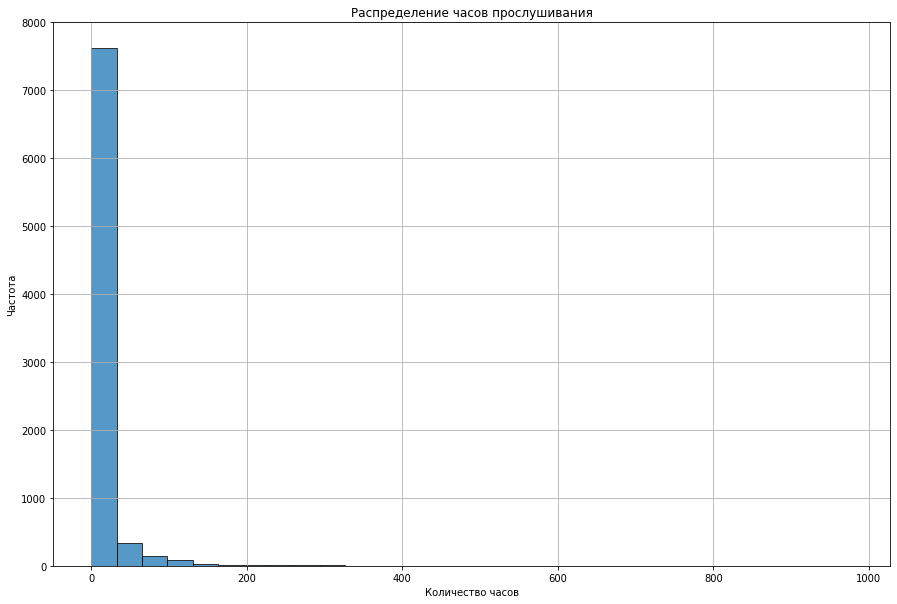

In [5]:
plt.figure(figsize=(15, 10))
df['hours'].plot(
            kind='hist',
            bins=30,
            alpha=0.75,
            edgecolor='black',
)

plt.title('Распределение часов прослушивания')
plt.xlabel('Количество часов')
plt.ylabel('Частота')
plt.grid()
plt.show() 

На графике мы видим гистограмму с наклоном вправо. Большинство пользователей сконцентрированно на значении до 200 часов. Я считаю что в данном случае никаких дополнительных действий проводить не нужно.

**Посчитаем количество пользователей в каждом городе:**

In [6]:
print('Количество пользователей в Москве:')
print(df[df['city'] == 'Москва']['puid'].nunique())
print('Количество пользователей в Санкт-Петербурге:')
print(df[df['city'] == 'Санкт-Петербург']['puid'].nunique())
print('Доля пользователей из Москвы:') 
print(round(100 * df[df['city'] == 'Москва']['puid'].nunique() / df['puid'].nunique()))
print('Доля пользователей из Санкт-Петербурга:') 
print(round(100 * df[df['city'] == 'Санкт-Петербург']['puid'].nunique() / df['puid'].nunique()))

Количество пользователей в Москве:
5990
Количество пользователей в Санкт-Петербурге:
2306
Доля пользователей из Москвы:
72
Доля пользователей из Санкт-Петербурга:
28


Как мы можем видеть, группы не сбалансированны. Количество слушателей в Москве, почти, в 2.5 раза превышает количество в Санкт-Петербурге. Исходя из данной информации, для проведения А/Б теста мы будет использовать **t-тест Уэлча**.

**Получим значения часов для каждого города:**

In [7]:
moscow_hours = df[df['city'] == 'Москва']['hours']
spb_hours = df[df['city'] == 'Санкт-Петербург']['hours']

**Рассчитаем среднее значение:**

In [8]:
moscow = df[df['city'] == 'Москва']['hours'].mean()
spb = df[df['city'] == 'Санкт-Петербург']['hours'].mean()

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [9]:
alpha = 0.05 

stat_welch_ttest, p_value_welch_ttest = ttest_ind(
    moscow_hours, 
    spb_hours, 
    equal_var=False,
    alternative='greater'
)
if p_value_welch_ttest>alpha:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны')
    print('Интерпретация: Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве')
else:
    print(f'p-value теста Уэлча ={round(p_value_welch_ttest, 2)}')
    print('Нулевая гипотеза не находит подтверждения! Выборочные средние в группах A и B не равны, и в группе B больше')
    print('Интерпретация: Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо')

p-value теста Уэлча =0.67
Нулевая гипотеза находит подтверждение! Выборочные средние в группах A и B равны
Интерпретация: Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



### Аналитическая записка

**1. Выбранный тип t-теста и уровень статистической значимости**

Для проверки гипотезы был использован **t-тест Уэлча** с односторонней альтернативой (greater). Выбор данного теста обусловлен следующими причинами:
- В отличие от классического t-теста Стьюдента, t-тест Уэлча не предполагает равенства дисперсий групп и устойчив к несбалансированности размера выборок (в нашем случае размер групп существенно различается: 5990 пользователей в Москве против 2306 в Санкт-Петербурге);
- Односторонняя проверка выбрана в соответствии с формулировкой гипотезы: нас интересует, что среднее время в Санкт-Петербурге **больше**, чем в Москве.

**Уровень статистической значимости (alpha):** 0.05 (5%).

**2. Результат теста (p-value)**

В результате проведения теста получено значение **p-value = 0.67**.

**3. Интерпретация результатов**

Полученное p-value (0.67) сильно превышает alpha. Это означает, что **у нас нет достаточных оснований отвергнуть нулевую гипотезу (H₀)**.

Следовательно, мы **не можем утверждать**, что среднее время активности пользователей из Санкт-Петербурга статистически значимо выше, чем среднее время активности пользователей из Москвы.

**4. Возможные причины полученных результатов**

1.  **Несбалансированность и недостаточный размер выборки.** Количество пользователей в группах сильно различается: пользователей из Москвы почти в 2.5 раза больше, чем из Санкт-Петербурга (5990 против 2306). При таком дисбалансе и относительно небольшой выборке из Петербурга, тест может обладать недостаточной статистической мощностью, чтобы уловить реальную разницу, даже если она существует в генеральной совокупности.

2.  **Особенности потребительского поведения.** В Санкт-Петербурге высокая концентрация творческой и гуманитарной молодежи, которая может отдавать предпочтение физическим книгам. В Москве же темп жизни выше, и жители могут чаще использовать мобильные приложения для чтения/прослушивания книг в метро или транспорте.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.

**Цель исследования:**
Провести оценку корректности и интерпритироватьт результаты А/Б-теста, проводимого компанией BitMotion Kit с целью подтверждения гипотезы о том, что новая версия сайта повысит количество пользователей, которые совершат покупку.

## 2. Загрузите данные, оцените их целостность.


In [10]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

**Посмотрим информацию о предоставленных данных:**

In [11]:
participants.info()
participants.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [12]:
events.info()
events.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


**Прорверка на пропуски:**

Проверка на пропуски в df `participants` не проводилась, т.к. из info видно что нет пустых строк в столбцах.
В df `events` есть пустые строки в столбце `details`, но, я считаю, что в данном столбце наличие пропусков это нормально, т.к. не всегда действия происходят с какой-то особенностью, поэтому я не буду что-то делать с этим.

**Проверим данные на наличие дубликатов:**

In [13]:
participants.duplicated().sum()

0

Явных дубликатов в данных нет, проверим наличие дубликатов по столбцу `user_id`:

In [14]:
participants['user_id'].duplicated().sum()
print("Количество дубликатов в столбце user_id:")
print(participants['user_id'].duplicated().sum())

duplicated_participants_id = participants[participants['user_id'].duplicated(keep=False)]
print(duplicated_participants_id.sort_values('user_id').head(10))

Количество дубликатов в столбце user_id:
887
             user_id group                  ab_test   device
1   001064FEAAB631A1     B  recommender_system_test  Android
2   001064FEAAB631A1     A        interface_eu_test  Android
9   00341D8401F0F665     A  recommender_system_test   iPhone
10  00341D8401F0F665     B        interface_eu_test   iPhone
25  0082295A41A867B5     A        interface_eu_test   iPhone
26  0082295A41A867B5     A  recommender_system_test   iPhone
41  00E68F103C66C1F7     A  recommender_system_test       PC
42  00E68F103C66C1F7     A        interface_eu_test       PC
45  00EFA157F7B6E1C4     B        interface_eu_test  Android
46  00EFA157F7B6E1C4     A  recommender_system_test  Android


Мы видим что в данных попадаются пользователи, которые участвуют сразу в двух тестах: "Тест интерфейса" и "тест рекомендательной системы". Эти два теста могут искажать данные друг друга, поэтому логичным решением будет удалить информацию об этих пользователях.

In [15]:
participants.drop_duplicates(subset=['user_id'], keep= False , inplace=True)

Проверим данные на наличие дубликатов в df `events`:

In [16]:
events.duplicated().sum()

36318

In [17]:
events = events.drop_duplicates().reset_index(drop=True)
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750968 entries, 0 to 750967
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     750968 non-null  object        
 1   event_dt    750968 non-null  datetime64[ns]
 2   event_name  750968 non-null  object        
 3   details     244905 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 22.9+ MB


Проверять данные на неявные дубликаты нет смысла, т.к. если их искать по столбцу `user_id`, то он выдаст результат, когда один и тот же пользователь совершает разные действия спустя время, например, заходит на сайт, регистрируется, добавляет товар в корзину и тп. Тоже самое по столбцу со временем события, т.к. у разных пользователей может быть одинаковое время совершения разных действий.

**Проверим количество участников в каждой группе:**

In [18]:
print('Количество пользователей в группе А:')
print(participants[(participants['ab_test'] == 'interface_eu_test') & (participants['group'] == 'A')]['user_id'].nunique())
print('Количество пользователей в группе B:')
print(participants[(participants['ab_test'] == 'interface_eu_test') & (participants['group'] == 'B')]['user_id'].nunique())
print('Доля пользователей в группе А:') 
print(round(100 * participants[(participants['ab_test'] == 'interface_eu_test') & (participants['group'] == 'A')]['user_id'].nunique() / participants['user_id'].nunique()))
print('Доля пользователей в группе B:') 
print(round(100 * participants[(participants['ab_test'] == 'interface_eu_test') & (participants['group'] == 'B')]['user_id'].nunique() / participants['user_id'].nunique()))

Количество пользователей в группе А:
4952
Количество пользователей в группе B:
5011
Доля пользователей в группе А:
39
Доля пользователей в группе B:
39


Мы можем видеть что группы разделены равномерно

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

**Данные проверки я проводил выше, вот основная информация:**
- **соответствие требованиям технического задания:**

Данные соответствуют требованиям технического задания.
- **равномерность распределения пользователей по группам теста:**

Количество пользователей в группе А:
**4952**

Количество пользователей в группе B:
**5011**

Доля пользователей в группе А:
**39**

Доля пользователей из Санкт-Петербурга:
**39**

Группы разделены равномерно.
- **отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах):**

В данных была информация о 887 пользователях, которые участвовали, одновременно, в двух тестах. Данные были очищены. 

3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

**Для решения данной задачи проделаем следующие шаги:**
- узнаем id пользователей участвующих в нашем тесте
- отфильтруем данные таблицы `events` по совпадающим id

In [19]:
interface_users = participants[participants['ab_test'] == 'interface_eu_test']['user_id'].unique()
events = events[events['user_id'].isin(interface_users)]

- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

**Для решения данной задачи проделаем следующие шаги:**
- найдем даты регистрации каждого пользователя
- присоединим таблицу с датами регистрации к основной таблице `events`
- добавим столбец `days_after_reg`, который будет рассчитывать количество дней между каждым событием после регистрации
- отфильтруем получившиеся значения в столбце `days_after_reg` в соответствии с условием, т.е. `days_after_reg` <= 7
- выведем на экран получившуюся таблицу

In [20]:
registration_dates = events[events['event_name'] == 'registration'][['user_id', 'event_dt']].rename(columns={'event_dt': 'reg_date'})
events_with_reg = events.merge(registration_dates, on='user_id')
events_with_reg['days_after_reg'] = (events_with_reg['event_dt'] - events_with_reg['reg_date']).dt.days
events_final = events_with_reg[events_with_reg['days_after_reg'] <= 7]
events_final.head()

,user_id,event_dt,event_name,details,reg_date,days_after_reg
0,5F506CEBEDC05D30,2020-12-06 14:10:01,registration,0.0,2020-12-06 14:10:01,0
1,5F506CEBEDC05D30,2020-12-07 01:25:14,login,NaN,2020-12-06 14:10:01,0
2,5F506CEBEDC05D30,2020-12-07 01:25:47,login,NaN,2020-12-06 14:10:01,0
3,5F506CEBEDC05D30,2020-12-09 12:40:49,login,NaN,2020-12-06 14:10:01,2
4,5F506CEBEDC05D30,2020-12-09 12:40:49,product_page,NaN,2020-12-06 14:10:01,2


Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

**Рассчитаем необходимы размер выборки:**

In [21]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

alpha = 0.05
beta = 0.2
power = 0.8
p = 0.30
mde = 0.03
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 3761


Учитывая что у нас в группах, примерно, по 5 тысяч человек, наша выборка вполне достаточна для корректных результатов.

- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

**Для решения данной задачи проделаем следующие шаги:**
- объединим таблицы `participants` и `events`
- посчитаем количество пользователей для каждой группы
- посчитаем количество пользователей, совершивших покупку, для каждой группы
- выведем полученный результат с просчитанной конверсией

In [22]:
union_data = participants.merge(events, on='user_id')
group_A_total = union_data[union_data['group'] == 'A']['user_id'].nunique()
group_B_total = union_data[union_data['group'] == 'B']['user_id'].nunique()

group_A_purchase = union_data[(union_data['group'] == 'A') & (union_data['event_name'] == 'purchase')]['user_id'].nunique()
group_B_purchase = union_data[(union_data['group'] == 'B') & (union_data['event_name'] == 'purchase')]['user_id'].nunique()

print(f'Группа A: {group_A_purchase} покупателей из {group_A_total} (CR = {round((group_A_purchase/group_A_total) * 100, 2)})')
print(f'Группа B: {group_B_purchase} покупателей из {group_B_total} (CR = {round((group_B_purchase/group_B_total) * 100, 2)})')

Группа A: 1638 покупателей из 4952 (CR = 33.08)
Группа B: 1782 покупателей из 5011 (CR = 35.56)


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

**Предварительный вывод:**

В тестовой группе конверсия составила 35.56%, в то время как в контрольной группе 33.08%. Таким образом количество покупателей выросло на 2.48%.

## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

**Сформулируем гипотезы:**

- Н0 - Если внедрить новый интерфейс онлайн-магазина, то количество пользователей, совершивших покупку между группами А и В будет равна.
- Н1 - Если внедрить новый интерфейс онлайн-магазина, то количество пользователей, совершивших покупку в группе В будет больше чем в группе А.

**Проводим А/B-тестирование:**

В данном случае необходимо воспользоваться Z-пропорцией:

In [23]:
from statsmodels.stats.proportion import proportions_ztest

n_a = group_A_total
n_b = group_B_total
m_a = group_A_purchase
m_b = group_B_purchase
p_a, p_b = m_a/n_a, m_b/n_b

print(f'n_a={n_a}, n_b={n_b}')
print(f'm_a={m_a}, m_b={m_b}')
print(f'p_a={p_a}, p_b={p_b}')

if (p_a * n_a > 10)and((1-p_a) * n_a > 10)and(p_b * n_b > 10)and((1-p_b) * n_b > 10):
    print('Предпосылка о достаточном количестве данных выполняется!')
else:
    print('Предпосылка о достаточном количестве данных НЕ выполняется!')

n_a=4952, n_b=5011
m_a=1638, m_b=1782
p_a=0.33077544426494343, p_b=0.3556176411893834
Предпосылка о достаточном количестве данных выполняется!


In [24]:
n_a, n_b = group_A_total, group_B_total
m_a, m_b = group_A_purchase, group_B_purchase

alpha = 0.05

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    #Так как H_1: p_a < p_b:
    alternative='smaller'
)
p_value_ztest

if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')

pvalue=0.004511578024761222 < 0.05
Нулевая гипотеза не находит подтверждения!


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

**Что можно сказать про результаты A/B-тестирования?**
- p-value = 0.0045 < α = 0.05

Это означает, что мы можем утверждать: новая версия интерфейса действительно привела к росту конверсии, и это не случайность.

**Краткие результаты теста**

| Показатель | Контрольная группа (A) | Тестовая группа (B) | Изменение |
|------------|------------------------|---------------------|-----------|
| Количество пользователей | 4 952 | 5 011 | - |
| Количество покупок | 1 638 | 1 782 | +144 |
| Конверсия | **33.08%** | **35.56%** | **+2.48 п.п.** |
| p-value | - | - | **0.0045** |

**Что можно сказать про результаты A/B-тестирования?**
- p-value = 0.0045 < α = 0.05

Это означает, что мы можем утверждать: новая версия интерфейса действительно привела к росту конверсии, и это не случайность.

**Был ли достигнут ожидаемый эффект?**
- Да, ожидаемый эффект достигнут

Ожидалось увеличение конверсии **на 3 процентных пункта** (с 30% до 33%):
- Фактический рост составил **+2.48 п.п.** (с 33.08% до 35.56%)
- Результат **статистически значим**